# Fit Label Classification Experiment

VITON-HD 이미지에서 수동 라벨링한 `tight / regular / oversized` 데이터를 사용하여 fit label classifier를 학습하고 평가합니다.

실험 범위는 다음까지입니다.

```text
dataset construction
→ stratified train / test split
→ feature extraction
→ classifier training
→ train set 내부 stratified 5-fold CV model selection
→ final test evaluation
```

미라벨 VTON 자동 라벨링 및 active learning은 본 노트북에서 제외합니다.

## 1. Install Packages

In [2]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q open_clip_torch xgboost scikit-learn matplotlib seaborn pandas tqdm joblib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00


## 2. Import Libraries

In [3]:
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import joblib

import torch
import torchvision.transforms as T
import clip
import open_clip

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
print("Libraries loaded")

Libraries loaded


## 3. Mount Google Drive

In [4]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted")
except ModuleNotFoundError:
    print("Not running on Colab. Skipping Drive mount.")

Mounted at /content/drive
Google Drive mounted


## 4. Config

`BASE_DIR`과 `EXPERIMENT_NAME`을 본인 실험에 맞게 수정하세요.

예상 데이터셋 구조:

```text
BASE_DIR/
├── dataset/
│   ├── tight/
│   ├── regular/
│   └── oversized/
├── embeddings/
├── models/
├── results/
│   ├── experiment_1/
│   ├── experiment_2/
│   └── ...
└── models/
    ├── experiment_1/
    ├── experiment_2/
    └── ...
```

하이퍼파라미터를 바꿔 실험할 때는 다음을 함께 수정하세요.

```python
EXPERIMENT_NAME = "experiment_2"
EXPERIMENT_NOTE = "Random Forest를 더 보수적으로 변경"
HYPERPARAMETER_CHANGE_NOTE = {
    "random_forest": "max_depth=5, min_samples_leaf=10으로 변경",
}
```

실험별 설정과 실제 classifier parameter는 `results/<EXPERIMENT_NAME>/experiment_setup.json`에 저장됩니다.


In [25]:
# Google Drive 안의 프로젝트 경로로 수정하세요.
BASE_DIR = Path("/content/drive/MyDrive/ML")

DATASET_DIR = BASE_DIR / "dataset"
EMBED_DIR = BASE_DIR / "embeddings"          # encoder embedding은 실험 간 공통 사용
MODEL_ROOT_DIR = BASE_DIR / "models"        # 실험별 model 저장 root
RESULT_ROOT_DIR = BASE_DIR / "results"      # 실험별 result 저장 root

# 하이퍼파라미터를 바꿔가며 실험할 때 이 이름만 experiment_2, experiment_3처럼 변경하세요.
EXPERIMENT_NAME = "experiment_10"

# 실험 노트: 이번 실험에서 무엇을 바꿨는지 적어둡니다.
EXPERIMENT_NOTE = (
    "experiment_9에서 rbf_svm의 C를 50.0으로 증가시켰지만, "
    "clip_vit_b32 + rbf_svm 조합의 성능이 현재 최고 조합인 "
    "clip_vit_b32 + linear_svm(C=15.0)보다 낮게 나타났다. "
    "이는 C=50.0이 과도하게 큰 값일 가능성이 있으므로, "
    "본 실험에서는 rbf_svm의 C를 30.0으로 낮추어 "
    "RBF SVM의 적절한 규제 강도 구간을 다시 확인한다."
)

HYPERPARAMETER_CHANGE_NOTE = {
    "knn_baseline": "변경 없음",
    "logistic_regression": "변경 없음",
    "linear_svm": "현재 최고 성능 설정 유지: C=15.0",
    "rbf_svm": "변경: experiment_9의 C=50.0에서 C=30.0으로 감소, gamma는 scale로 유지",
    "random_forest": "변경 없음",
    "xgboost": "변경 없음",
}

MODEL_DIR = MODEL_ROOT_DIR / EXPERIMENT_NAME
RESULT_DIR = RESULT_ROOT_DIR / EXPERIMENT_NAME

LABEL_NAMES = ["tight", "regular", "oversized"]
LABEL_MAP = {label: idx for idx, label in enumerate(LABEL_NAMES)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_MAP.items()}

RANDOM_STATE = 42
BATCH_SIZE = 32
TEST_SIZE = 0.15
RUN_KFOLD_CV = True
N_SPLITS = 5
FORCE_REBUILD_EMBEDDINGS = False  # 첫 실행 또는 split 변경 후에는 True 권장. 생성 완료 후 재실행 시 False로 변경 가능.

# 실행할 embedding model을 선택합니다.
# DINOv2는 처음 실행 시 torch hub에서 모델을 다운로드합니다.
ENCODER_CONFIGS = {
    "clip_vit_b32": {
        "type": "openai_clip",
        "model_name": "ViT-B/32",
    },
    "openclip_vit_l14": {
        "type": "openclip",
        "model_name": "ViT-L-14",
        "pretrained": "laion2b_s32b_b82k",
    },
    "dinov2_vit_b14": {
        "type": "dinov2",
        "model_name": "dinov2_vitb14",
    },
}

RUN_ENCODERS = ["clip_vit_b32", "openclip_vit_l14", "dinov2_vit_b14"]

for directory in [EMBED_DIR, MODEL_ROOT_DIR, RESULT_ROOT_DIR, MODEL_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

with open(RESULT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(LABEL_MAP, f, indent=2, ensure_ascii=False)

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATASET_DIR: {DATASET_DIR}")
print(f"EXPERIMENT_NAME: {EXPERIMENT_NAME}")
print(f"RESULT_DIR: {RESULT_DIR}")
print(f"MODEL_DIR: {MODEL_DIR}")
print(f"LABEL_MAP: {LABEL_MAP}")

BASE_DIR: /content/drive/MyDrive/ML
DATASET_DIR: /content/drive/MyDrive/ML/dataset
EXPERIMENT_NAME: experiment_10
RESULT_DIR: /content/drive/MyDrive/ML/results/experiment_10
MODEL_DIR: /content/drive/MyDrive/ML/models/experiment_10
LABEL_MAP: {'tight': 0, 'regular': 1, 'oversized': 2}


## 5. Device

In [8]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: cpu


## 6. Load and Validate Dataset

In [9]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def file_hash(path: Path) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def collect_dataset(dataset_dir: Path) -> pd.DataFrame:
    rows = []
    for label in LABEL_NAMES:
        label_dir = dataset_dir / label
        if not label_dir.exists():
            raise FileNotFoundError(f"Missing label directory: {label_dir}")

        for path in sorted(label_dir.rglob("*")):
            if not path.is_file() or path.suffix.lower() not in IMAGE_EXTS:
                continue
            if not is_valid_image(path):
                print(f"[SKIP] Invalid image: {path}")
                continue

            rows.append({
                "path": str(path),
                "filename": path.name,
                "label": label,
                "label_id": LABEL_MAP[label],
                "hash": file_hash(path),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No images found in {dataset_dir}")
    return df


df = collect_dataset(DATASET_DIR)

print("Dataset size:", len(df))
print(df["label"].value_counts().reindex(LABEL_NAMES))

duplicates = df[df.duplicated("hash", keep=False)].sort_values("hash")
if len(duplicates) > 0:
    print(f"\n[WARN] Duplicate candidate images: {len(duplicates)}")
    display(duplicates[["label", "filename", "hash"]].head(20))
else:
    print("No duplicate images detected by hash.")

Dataset size: 450
label
tight        150
regular      150
oversized    150
Name: count, dtype: int64
No duplicate images detected by hash.


## 7. Stratified Train / Test Split

전체 데이터에서 test set을 먼저 분리합니다. Test set은 최종 평가에만 사용하고, 모델 선택은 train set 내부의 Stratified 5-fold CV로 수행합니다.

In [10]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

train_df = train_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
test_df["split"] = "test"

manifest_df = pd.concat([train_df, test_df], ignore_index=True)
manifest_path = RESULT_DIR / "manifest.csv"
manifest_df.to_csv(manifest_path, index=False, encoding="utf-8-sig")

print(manifest_df.groupby(["split", "label"]).size())
print(f"\nSaved manifest: {manifest_path}")

split  label    
test   oversized     22
       regular       23
       tight         23
train  oversized    128
       regular      127
       tight        127
dtype: int64

Saved manifest: /content/drive/MyDrive/ML/results/experiment_1/manifest.csv


## 8. Feature Extractor Loading Functions

In [11]:
def load_feature_extractor(encoder_key: str):
    cfg = ENCODER_CONFIGS[encoder_key]
    encoder_type = cfg["type"]

    if encoder_type == "openai_clip":
        model, preprocess = clip.load(cfg["model_name"], device=device)
        model.eval()

        def encode(batch_tensor):
            return model.encode_image(batch_tensor).float()

        return model, preprocess, encode

    if encoder_type == "openclip":
        model, _, preprocess = open_clip.create_model_and_transforms(
            cfg["model_name"],
            pretrained=cfg["pretrained"],
            device=device,
        )
        model.eval()

        def encode(batch_tensor):
            return model.encode_image(batch_tensor).float()

        return model, preprocess, encode

    if encoder_type == "dinov2":
        model = torch.hub.load("facebookresearch/dinov2", cfg["model_name"])
        model = model.to(device)
        model.eval()

        preprocess = T.Compose([
            T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
            T.CenterCrop(224),
            T.ToTensor(),
            T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

        def encode(batch_tensor):
            return model(batch_tensor).float()

        return model, preprocess, encode

    raise ValueError(f"Unknown encoder type: {encoder_type}")


def l2_normalize(features: torch.Tensor) -> torch.Tensor:
    return features / features.norm(dim=-1, keepdim=True).clamp(min=1e-12)

## 9. Extract and Save Embeddings

In [12]:
SPLIT_DFS = {
    "train": train_df,
    "test": test_df,
}


def extract_embeddings_for_split(split_df: pd.DataFrame, preprocess, encode, split_name: str):
    image_paths = [Path(p) for p in split_df["path"].tolist()]
    labels = split_df["label_id"].to_numpy(dtype=np.int64)
    all_features = []

    for start in tqdm(range(0, len(image_paths), BATCH_SIZE), desc=f"{split_name}"):
        batch_paths = image_paths[start:start + BATCH_SIZE]
        batch_images = []

        for path in batch_paths:
            image = Image.open(path).convert("RGB")
            batch_images.append(preprocess(image))

        batch_tensor = torch.stack(batch_images).to(device)

        with torch.no_grad():
            features = encode(batch_tensor)
            features = l2_normalize(features)

        all_features.append(features.cpu().numpy())

    X = np.vstack(all_features).astype(np.float32)
    return X, labels, np.array([str(p) for p in image_paths])


def extract_and_save_encoder(encoder_key: str, force: bool = False):
    encoder_dir = EMBED_DIR / encoder_key
    encoder_dir.mkdir(parents=True, exist_ok=True)

    expected_files = [encoder_dir / f"{split}.npz" for split in SPLIT_DFS]
    if not force and all(path.exists() for path in expected_files):
        print(f"[SKIP] Existing embeddings found: {encoder_key}")
        return

    print(f"\nLoading encoder: {encoder_key}")
    model, preprocess, encode = load_feature_extractor(encoder_key)

    for split_name, split_df in SPLIT_DFS.items():
        X, y, paths = extract_embeddings_for_split(split_df, preprocess, encode, split_name)
        np.savez_compressed(
            encoder_dir / f"{split_name}.npz",
            embeddings=X,
            labels=y,
            paths=paths,
        )
        print(f"Saved {encoder_key}/{split_name}.npz: {X.shape}")

    del model
    if device == "cuda":
        torch.cuda.empty_cache()


for encoder_key in RUN_ENCODERS:
    extract_and_save_encoder(encoder_key, force=FORCE_REBUILD_EMBEDDINGS)


Loading encoder: clip_vit_b32


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 79.4MiB/s]


train:   0%|          | 0/12 [00:00<?, ?it/s]

Saved clip_vit_b32/train.npz: (382, 512)


test:   0%|          | 0/3 [00:00<?, ?it/s]

...

100%|██████████| 330M/330M [00:01<00:00, 193MB/s]


train:   0%|          | 0/12 [00:00<?, ?it/s]

Saved dinov2_vit_b14/train.npz: (382, 768)


test:   0%|          | 0/3 [00:00<?, ?it/s]

Saved dinov2_vit_b14/test.npz: (68, 768)


## 10. Classifier Definitions

본 노트북은 우선 추천 기본값으로 모델을 비교합니다. 하이퍼파라미터 탐색은 이후 상위 조합에 대해서만 별도 수행하는 것을 권장합니다.

In [27]:
def build_classifiers():
    return {
        "knn_baseline": KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="cosine",
        ),
        "logistic_regression": LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight=None,
            random_state=RANDOM_STATE,
        ),
        "linear_svm": CalibratedClassifierCV(
            LinearSVC(
                C=15.0,
                class_weight=None,
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
            cv=3,
        ),
        "rbf_svm": CalibratedClassifierCV(
            SVC(
                kernel="rbf",
                C=30.0,
                gamma="scale",
                class_weight=None,
                probability=False,
                random_state=RANDOM_STATE,
            ),
            cv=3,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "xgboost": XGBClassifier(
            objective="multi:softprob",
            num_class=len(LABEL_NAMES),
            n_estimators=200,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.7,
            min_child_weight=5,
            reg_alpha=0.1,
            reg_lambda=2.0,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }


print(list(build_classifiers().keys()))


def make_json_safe(value):
    """Estimator parameters can include numpy values or objects; convert them for JSON logging."""
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    if isinstance(value, (list, tuple)):
        return [make_json_safe(v) for v in value]
    if isinstance(value, dict):
        return {str(k): make_json_safe(v) for k, v in value.items()}
    if isinstance(value, np.generic):
        return value.item()
    return repr(value)


def get_classifier_param_log():
    param_log = {}
    for clf_name, clf in build_classifiers().items():
        if hasattr(clf, "get_params"):
            param_log[clf_name] = make_json_safe(clf.get_params(deep=True))
        else:
            param_log[clf_name] = repr(clf)
    return param_log


experiment_setup = {
    "experiment_name": EXPERIMENT_NAME,
    "experiment_note": EXPERIMENT_NOTE,
    "hyperparameter_change_note": HYPERPARAMETER_CHANGE_NOTE,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_splits": N_SPLITS,
    "run_encoders": RUN_ENCODERS,
    "encoder_configs": ENCODER_CONFIGS,
    "label_map": LABEL_MAP,
    "classifier_parameters": get_classifier_param_log(),
}

experiment_setup_path = RESULT_DIR / "experiment_setup.json"
with open(experiment_setup_path, "w", encoding="utf-8") as f:
    json.dump(experiment_setup, f, indent=2, ensure_ascii=False)

def summarize_classifier_params() -> pd.DataFrame:
    """사람이 읽기 쉬운 형태로 핵심 하이퍼파라미터만 요약합니다."""
    classifiers = build_classifiers()
    rows = []

    for clf_name, clf in classifiers.items():
        params = clf.get_params(deep=True) if hasattr(clf, "get_params") else {}

        if clf_name == "knn_baseline":
            important = {
                "n_neighbors": params.get("n_neighbors"),
                "weights": params.get("weights"),
                "metric": params.get("metric"),
            }
        elif clf_name == "logistic_regression":
            important = {
                "C": params.get("C"),
                "penalty": params.get("penalty"),
                "solver": params.get("solver"),
                "max_iter": params.get("max_iter"),
                "class_weight": params.get("class_weight"),
            }
        elif clf_name == "linear_svm":
            important = {
                "estimator__C": params.get("estimator__C"),
                "estimator__class_weight": params.get("estimator__class_weight"),
                "estimator__max_iter": params.get("estimator__max_iter"),
                "cv": params.get("cv"),
            }
        elif clf_name == "rbf_svm":
            important = {
                "estimator__kernel": params.get("estimator__kernel"),
                "estimator__C": params.get("estimator__C"),
                "estimator__gamma": params.get("estimator__gamma"),
                "estimator__class_weight": params.get("estimator__class_weight"),
                "cv": params.get("cv"),
            }
        elif clf_name == "random_forest":
            important = {
                "n_estimators": params.get("n_estimators"),
                "max_depth": params.get("max_depth"),
                "min_samples_leaf": params.get("min_samples_leaf"),
                "min_samples_split": params.get("min_samples_split"),
                "max_features": params.get("max_features"),
                "class_weight": params.get("class_weight"),
            }
        elif clf_name == "xgboost":
            important = {
                "n_estimators": params.get("n_estimators"),
                "max_depth": params.get("max_depth"),
                "learning_rate": params.get("learning_rate"),
                "subsample": params.get("subsample"),
                "colsample_bytree": params.get("colsample_bytree"),
                "min_child_weight": params.get("min_child_weight"),
                "reg_alpha": params.get("reg_alpha"),
                "reg_lambda": params.get("reg_lambda"),
            }
        else:
            important = make_json_safe(params)

        rows.append({
            "experiment": EXPERIMENT_NAME,
            "classifier": clf_name,
            "change_note": HYPERPARAMETER_CHANGE_NOTE.get(clf_name, ""),
            "important_parameters": json.dumps(make_json_safe(important), ensure_ascii=False),
        })

    return pd.DataFrame(rows)


hyperparameter_summary = summarize_classifier_params()
hyperparameter_summary_path = RESULT_DIR / "hyperparameter_summary.csv"
hyperparameter_summary.to_csv(hyperparameter_summary_path, index=False, encoding="utf-8-sig")

hyperparameter_md_path = RESULT_DIR / "hyperparameter_summary.md"
with open(hyperparameter_md_path, "w", encoding="utf-8") as f:
    f.write(f"# Hyperparameter Summary - {EXPERIMENT_NAME}\n\n")
    f.write(f"## Experiment Note\n\n{EXPERIMENT_NOTE}\n\n")
    f.write("## Classifier Parameters\n\n")
    for _, row in hyperparameter_summary.iterrows():
        f.write(f"### {row['classifier']}\n\n")
        f.write(f"- Change note: {row['change_note']}\n")
        f.write(f"- Important parameters: `{row['important_parameters']}`\n\n")

display(hyperparameter_summary)
print(f"Saved experiment setup: {experiment_setup_path}")
print(f"Saved hyperparameter summary CSV: {hyperparameter_summary_path}")
print(f"Saved hyperparameter summary Markdown: {hyperparameter_md_path}")


['knn_baseline', 'logistic_regression', 'linear_svm', 'rbf_svm', 'random_forest', 'xgboost']


,experiment,classifier,change_note,important_parameters
0,experiment_10,knn_baseline,변경 없음,"{""n_neighbors"": 5, ""weights"": ""distance"", ""met..."
1,experiment_10,logistic_regression,변경 없음,"{""C"": 1.0, ""penalty"": ""l2"", ""solver"": ""lbfgs"",..."
2,experiment_10,linear_svm,현재 최고 성능 설정 유지: C=15.0,"{""estimator__C"": 15.0, ""estimator__class_weigh..."
3,experiment_10,rbf_svm,"변경: experiment_9의 C=50.0에서 C=30.0으로 감소, gamma는...","{""estimator__kernel"": ""rbf"", ""estimator__C"": 3..."
4,experiment_10,random_forest,변경 없음,"{""n_estimators"": 500, ""max_depth"": 8, ""min_sam..."
5,experiment_10,xgboost,변경 없음,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."


Saved experiment setup: /content/drive/MyDrive/ML/results/experiment_10/experiment_setup.json
Saved hyperparameter summary CSV: /content/drive/MyDrive/ML/results/experiment_10/hyperparameter_summary.csv
Saved hyperparameter summary Markdown: /content/drive/MyDrive/ML/results/experiment_10/hyperparameter_summary.md


## 11. Metrics

In [28]:
def ordinal_mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def evaluate_predictions(y_true, y_pred) -> dict:
    recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(LABEL_NAMES))))
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "ordinal_mae": ordinal_mae(y_true, y_pred),
    }
    for idx, label in enumerate(LABEL_NAMES):
        metrics[f"recall_{label}"] = recalls[idx]
    return {key: float(value) for key, value in metrics.items()}


def load_split_embeddings(encoder_key: str):
    encoder_dir = EMBED_DIR / encoder_key
    data = {}
    for split in ["train", "test"]:
        npz = np.load(encoder_dir / f"{split}.npz", allow_pickle=True)
        data[split] = {
            "X": npz["embeddings"],
            "y": npz["labels"],
            "paths": npz["paths"],
        }
    return data

## 12. Stratified 5-Fold Cross Validation on Train Set

각 encoder/classifier 조합을 train set 내부에서 Stratified 5-fold CV로 비교합니다. Test set은 이 과정에 사용하지 않습니다.

최종 모델 선택 기준은 CV 평균 `macro_f1`입니다.

In [29]:
cv_detail_rows = []

if not RUN_KFOLD_CV:
    raise ValueError("This experiment pipeline requires RUN_KFOLD_CV = True.")

for encoder_key in RUN_ENCODERS:
    split_data = load_split_embeddings(encoder_key)
    X_train = split_data["train"]["X"]
    y_train = split_data["train"]["y"]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    print(f"\n=== {encoder_key}: {N_SPLITS}-fold CV on train set ===")

    for clf_name in build_classifiers().keys():
        fold_metrics = []

        for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            clf = build_classifiers()[clf_name]
            clf.fit(X_train[fold_train_idx], y_train[fold_train_idx])
            y_fold_pred = clf.predict(X_train[fold_val_idx])
            metrics = evaluate_predictions(y_train[fold_val_idx], y_fold_pred)

            row = {
                "experiment": EXPERIMENT_NAME,
                "encoder": encoder_key,
                "classifier": clf_name,
                "fold": fold_idx,
                **metrics,
            }
            cv_detail_rows.append(row)
            fold_metrics.append(metrics["macro_f1"])

        print(f"{clf_name:<22} Macro F1: {np.mean(fold_metrics):.4f} ± {np.std(fold_metrics):.4f}")

cv_detail = pd.DataFrame(cv_detail_rows)
cv_summary = (
    cv_detail
    .groupby(["encoder", "classifier"])
    .agg({
        "accuracy": ["mean", "std"],
        "macro_f1": ["mean", "std"],
        "ordinal_mae": ["mean", "std"],
        "recall_tight": "mean",
        "recall_regular": "mean",
        "recall_oversized": "mean",
    })
)
cv_summary.columns = ["_".join(col).strip("_") for col in cv_summary.columns.values]
cv_summary = cv_summary.reset_index().sort_values(
    ["macro_f1_mean", "ordinal_mae_mean", "accuracy_mean"],
    ascending=[False, True, False],
)

cv_detail_path = RESULT_DIR / "cv_detail_results.csv"
cv_summary_path = RESULT_DIR / "cv_summary_results.csv"
cv_detail.to_csv(cv_detail_path, index=False, encoding="utf-8-sig")
cv_summary.to_csv(cv_summary_path, index=False, encoding="utf-8-sig")

display(cv_summary)
print(f"Saved CV detail: {cv_detail_path}")
print(f"Saved CV summary: {cv_summary_path}")


=== clip_vit_b32: 5-fold CV on train set ===
knn_baseline           Macro F1: 0.7857 ± 0.0292
logistic_regression    Macro F1: 0.8574 ± 0.0591
linear_svm             Macro F1: 0.9215 ± 0.0132
rbf_svm                Macro F1: 0.9034 ± 0.0191
random_forest          Macro F1: 0.8631 ± 0.0478
xgboost                Macro F1: 0.8437 ± 0.0356

=== openclip_vit_l14: 5-fold CV on train set ===
knn_baseline           Macro F1: 0.7994 ± 0.0620
logistic_regression    Macro F1: 0.8908 ± 0.0359
linear_svm             Macro F1: 0.8839 ± 0.0277
rbf_svm                Macro F1: 0.8943 ± 0.0321
random_forest          Macro F1: 0.8751 ± 0.0550
xgboost                Macro F1: 0.8744 ± 0.0424

=== dinov2_vit_b14: 5-fold CV on train set ===
knn_baseline           Macro F1: 0.7950 ± 0.0347
logistic_regression    Macro F1: 0.8411 ± 0.0465
linear_svm             Macro F1: 0.8623 ± 0.0510
rbf_svm                Macro F1: 0.8712 ± 0.0535
random_forest          Macro F1: 0.8320 ± 0.0350
xgboost                

,encoder,classifier,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,ordinal_mae_mean,ordinal_mae_std,recall_tight_mean,recall_regular_mean,recall_oversized_mean
1,clip_vit_b32,linear_svm,0.921531,0.015561,0.921455,0.014720,0.078469,0.015561,0.937538,0.881538,0.944923
4,clip_vit_b32,rbf_svm,0.903178,0.021578,0.903375,0.021408,0.096822,0.021578,0.921846,0.857846,0.929538
16,openclip_vit_l14,rbf_svm,0.895386,0.035527,0.894329,0.035848,0.104614,0.035527,0.952923,0.834462,0.897538
14,openclip_vit_l14,logistic_regression,0.892789,0.039155,0.890777,0.040173,0.107211,0.039155,0.968923,0.803077,0.905538
13,openclip_vit_l14,linear_svm,0.884928,0.030703,0.883854,0.030974,0.115072,0.030703,0.952923,0.803385,0.897846
15,openclip_vit_l14,random_forest,0.877033,0.060145,0.875064,0.061503,0.122967,0.060145,0.937538,0.787077,0.905846
17,openclip_vit_l14,xgboost,0.876965,0.044058,0.874404,0.047401,0.125666,0.048766,0.952923,0.778462,0.897538
10,dinov2_vit_b14,rbf_svm,0.871805,0.060766,0.871231,0.059837,0.128195,0.060766,0.921231,0.787385,0.905538
3,clip_vit_b32,random_forest,0.866336,0.048014,0.863123,0.053464,0.136295,0.049120,0.921231,0.762154,0.913846
7,dinov2_vit_b14,linear_svm,0.864046,0.056216,0.862271,0.056966,0.135954,0.056216,0.936923,0.756308,0.897231


Saved CV detail: /content/drive/MyDrive/ML/results/experiment_10/cv_detail_results.csv
Saved CV summary: /content/drive/MyDrive/ML/results/experiment_10/cv_summary_results.csv


## 13. Select Best Model

CV 평균 Macro F1이 가장 높은 encoder/classifier 조합을 최종 모델로 선택합니다.

In [30]:
best_row = cv_summary.iloc[0].to_dict()
BEST_ENCODER = best_row["encoder"]
BEST_CLASSIFIER = best_row["classifier"]
SELECTION_METHOD = "stratified_5fold_cv_on_train"

print(f"Experiment: {EXPERIMENT_NAME}")
print("Best model selected by Stratified 5-fold CV on train set")
print(f"  encoder       : {BEST_ENCODER}")
print(f"  classifier    : {BEST_CLASSIFIER}")
print(f"  macro_f1_mean : {best_row['macro_f1_mean']:.4f}")
print(f"  macro_f1_std  : {best_row['macro_f1_std']:.4f}")
print(f"  accuracy_mean : {best_row['accuracy_mean']:.4f}")
print(f"  ordinal_mae   : {best_row['ordinal_mae_mean']:.4f}")

Experiment: experiment_10
Best model selected by Stratified 5-fold CV on train set
  encoder       : clip_vit_b32
  classifier    : linear_svm
  macro_f1_mean : 0.9215
  macro_f1_std  : 0.0147
  accuracy_mean : 0.9215
  ordinal_mae   : 0.0785


## 14. 최종 모델 선택

실험 1~8에서는 train set에 대해서만 stratified 5-fold cross validation을 수행하여 classifier의 하이퍼파라미터를 조정하였다.

그 결과 `experiment_7`이 가장 좋은 CV 성능을 보였으며, 해당 실험에서는 이미지 인코더로 `clip_vit_b32`, 분류기로 `linear_svm`을 사용하였다. Linear SVM의 주요 하이퍼파라미터인 `C`는 `15`로 설정하였다.

실험 과정에서 `C` 값을 점진적으로 증가시켰을 때 `C=15`까지는 성능이 향상되었지만, `C=20`과 `C=30`에서는 성능이 다시 감소하였다. 따라서 본 실험에서는 `C=15`를 최종 regularization strength로 선택하였다.

Test set은 모델 선택 과정에 사용하지 않았으며, 최종 모델이 결정된 이후 최종 성능 확인을 위해 한 번만 사용한다.

In [44]:
# ============================================================
# 14. 최종 모델 선택
# ============================================================

FINAL_EXPERIMENT_NAME = "experiment_7"
FINAL_ENCODER = "clip_vit_b32"
FINAL_CLASSIFIER = "linear_svm"

EXPERIMENT_NAME = FINAL_EXPERIMENT_NAME
BEST_ENCODER = FINAL_ENCODER
BEST_CLASSIFIER = FINAL_CLASSIFIER
SELECTION_METHOD = "manual_selection_after_cv_hyperparameter_search"

RESULT_DIR = RESULT_ROOT_DIR / EXPERIMENT_NAME
MODEL_DIR = MODEL_ROOT_DIR / EXPERIMENT_NAME
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CLASSIFIER_PARAMS = {
    "classifier": "linear_svm",
    "C": 15.0,
    "class_weight": None,
    "max_iter": 5000,
    "calibration_cv": 3,
    "random_state": RANDOM_STATE,
}

FINAL_SELECTION_NOTE = (
    "Experiment 7 was selected as the final model based on stratified 5-fold CV. "
    "Linear SVM performance improved as C increased up to 15, but decreased again at C=20 and C=30. "
    "Therefore, C=15 was selected as the best regularization strength."
)

print("Final selected model")
print("=" * 70)
print(f"Experiment : {EXPERIMENT_NAME}")
print(f"Encoder    : {BEST_ENCODER}")
print(f"Classifier : {BEST_CLASSIFIER}")
print(f"Parameters : {FINAL_CLASSIFIER_PARAMS}")
print(f"Result dir : {RESULT_DIR}")
print(f"Model dir  : {MODEL_DIR}")
print("=" * 70)

# 선택한 experiment_7의 CV 결과 확인
cv_summary_path = RESULT_DIR / "cv_summary_results.csv"

if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)

    selected_cv_row = cv_summary[
        (cv_summary["encoder"] == BEST_ENCODER) &
        (cv_summary["classifier"] == BEST_CLASSIFIER)
    ].copy()

    if len(selected_cv_row) == 0:
        print("[WARN] 선택한 encoder/classifier 조합이 cv_summary_results.csv에 없습니다.")
        display(cv_summary.head())
    else:
        selected_cv_row = selected_cv_row.iloc[[0]]
        display(selected_cv_row)

        print("\nSelected CV Result")
        print("=" * 70)
        print(f"Macro F1      : {selected_cv_row.iloc[0]['macro_f1_mean']:.4f} ± {selected_cv_row.iloc[0]['macro_f1_std']:.4f}")
        print(f"Accuracy      : {selected_cv_row.iloc[0]['accuracy_mean']:.4f}")
        print(f"Ordinal MAE   : {selected_cv_row.iloc[0]['ordinal_mae_mean']:.4f}")
        print(f"Recall tight  : {selected_cv_row.iloc[0]['recall_tight_mean']:.4f}")
        print(f"Recall regular: {selected_cv_row.iloc[0]['recall_regular_mean']:.4f}")
        print(f"Recall over   : {selected_cv_row.iloc[0]['recall_oversized_mean']:.4f}")
        print("=" * 70)
else:
    selected_cv_row = None
    print(f"[WARN] CV summary file not found: {cv_summary_path}")

# 최종 모델 선택 기록 저장
final_selection_info = {
    "final_experiment_name": FINAL_EXPERIMENT_NAME,
    "final_encoder": FINAL_ENCODER,
    "final_classifier": FINAL_CLASSIFIER,
    "selection_method": SELECTION_METHOD,
    "final_classifier_params": FINAL_CLASSIFIER_PARAMS,
    "selection_note": FINAL_SELECTION_NOTE,
}

if selected_cv_row is not None and len(selected_cv_row) > 0:
    final_selection_info["cv_result"] = selected_cv_row.iloc[0].to_dict()

final_selection_json_path = RESULT_DIR / "final_model_selection.json"
with open(final_selection_json_path, "w", encoding="utf-8") as f:
    json.dump(final_selection_info, f, indent=2, ensure_ascii=False)

final_selection_md_path = RESULT_DIR / "final_model_selection.md"
with open(final_selection_md_path, "w", encoding="utf-8") as f:
    f.write("# Final Model Selection\n\n")
    f.write(f"- Final experiment: `{FINAL_EXPERIMENT_NAME}`\n")
    f.write(f"- Encoder: `{FINAL_ENCODER}`\n")
    f.write(f"- Classifier: `{FINAL_CLASSIFIER}`\n")
    f.write(f"- Parameters: `{FINAL_CLASSIFIER_PARAMS}`\n")
    f.write(f"- Selection method: `{SELECTION_METHOD}`\n\n")
    f.write("## Selection Note\n\n")
    f.write(FINAL_SELECTION_NOTE + "\n\n")

    if selected_cv_row is not None and len(selected_cv_row) > 0:
        row = selected_cv_row.iloc[0]
        f.write("## CV Result\n\n")
        f.write(f"- Macro F1: {row['macro_f1_mean']:.4f} ± {row['macro_f1_std']:.4f}\n")
        f.write(f"- Accuracy: {row['accuracy_mean']:.4f}\n")
        f.write(f"- Ordinal MAE: {row['ordinal_mae_mean']:.4f}\n")
        f.write(f"- Recall tight: {row['recall_tight_mean']:.4f}\n")
        f.write(f"- Recall regular: {row['recall_regular_mean']:.4f}\n")
        f.write(f"- Recall oversized: {row['recall_oversized_mean']:.4f}\n")

print(f"\nSaved final selection JSON: {final_selection_json_path}")
print(f"Saved final selection Markdown: {final_selection_md_path}")


def build_final_classifier():
    """최종 선택된 Experiment 7 모델 설정을 그대로 재현합니다."""
    return CalibratedClassifierCV(
        LinearSVC(
            C=15.0,
            class_weight=None,
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        cv=3,
    )

Final selected model
Experiment : experiment_7
Encoder    : clip_vit_b32
Classifier : linear_svm
Parameters : {'classifier': 'linear_svm', 'C': 15.0, 'class_weight': None, 'max_iter': 5000, 'calibration_cv': 3, 'random_state': 42}
Result dir : /content/drive/MyDrive/ML/results/experiment_7
Model dir  : /content/drive/MyDrive/ML/models/experiment_7


,encoder,classifier,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,ordinal_mae_mean,ordinal_mae_std,recall_tight_mean,recall_regular_mean,recall_oversized_mean
0,clip_vit_b32,linear_svm,0.921531,0.015561,0.921455,0.01472,0.078469,0.015561,0.937538,0.881538,0.944923



Selected CV Result
Macro F1      : 0.9215 ± 0.0147
Accuracy      : 0.9215
Ordinal MAE   : 0.0785
Recall tight  : 0.9375
Recall regular: 0.8815
Recall over   : 0.9449

Saved final selection JSON: /content/drive/MyDrive/ML/results/experiment_7/final_model_selection.json
Saved final selection Markdown: /content/drive/MyDrive/ML/results/experiment_7/final_model_selection.md


## 15. 최종 Test 평가

Cross validation을 통해 선택된 최종 모델을 전체 train set으로 다시 학습한 뒤, 별도로 분리해둔 test set에서 최종 성능을 평가한다.

이 test 평가는 최종 보고서에 사용할 성능 확인용 결과이며, 추가적인 하이퍼파라미터 튜닝이나 모델 선택에는 사용하지 않는다.

In [45]:
# ============================================================
# 15. 최종 Test 평가
# ============================================================

split_data = load_split_embeddings(BEST_ENCODER)

X_train = split_data["train"]["X"]
y_train = split_data["train"]["y"]
X_test = split_data["test"]["X"]
y_test = split_data["test"]["y"]

final_model = build_final_classifier()
final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)

test_metrics = evaluate_predictions(y_test, y_test_pred)

test_report = classification_report(
    y_test,
    y_test_pred,
    target_names=LABEL_NAMES,
    output_dict=True,
)

test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=list(range(len(LABEL_NAMES))),
)

print("Final Test Metrics")
print("=" * 70)
for key, value in test_metrics.items():
    print(f"{key:<18}: {value:.4f}")

print("\nClassification Report")
print("=" * 70)
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES))

final_model_path = MODEL_DIR / f"best_{BEST_ENCODER}_{BEST_CLASSIFIER}.joblib"
joblib.dump(final_model, final_model_path)

test_metrics_path = RESULT_DIR / "test_metrics.json"
with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump({
        "experiment_name": EXPERIMENT_NAME,
        "selection_method": SELECTION_METHOD,
        "best_encoder": BEST_ENCODER,
        "best_classifier": BEST_CLASSIFIER,
        "final_classifier_params": FINAL_CLASSIFIER_PARAMS,
        "selection_note": FINAL_SELECTION_NOTE,
        "metrics": test_metrics,
        "classification_report": test_report,
    }, f, indent=2, ensure_ascii=False)

print(f"\nSaved final model: {final_model_path}")
print(f"Saved test metrics: {test_metrics_path}")

Final Test Metrics
accuracy          : 0.9265
macro_f1          : 0.9268
ordinal_mae       : 0.0735
recall_tight      : 0.9565
recall_regular    : 0.9130
recall_oversized  : 0.9091

Classification Report
              precision    recall  f1-score   support

       tight       1.00      0.96      0.98        23
     regular       0.88      0.91      0.89        23
   oversized       0.91      0.91      0.91        22

    accuracy                           0.93        68
   macro avg       0.93      0.93      0.93        68
weighted avg       0.93      0.93      0.93        68


Saved final model: /content/drive/MyDrive/ML/models/experiment_7/best_clip_vit_b32_linear_svm.joblib
Saved test metrics: /content/drive/MyDrive/ML/results/experiment_7/test_metrics.json


## 16. Confusion Matrix

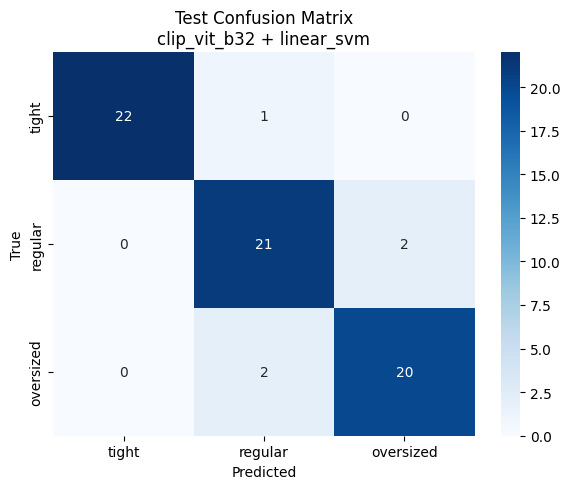

Saved confusion matrix: /content/drive/MyDrive/ML/results/experiment_7/test_confusion_matrix.png


In [46]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.title(f"Test Confusion Matrix\n{BEST_ENCODER} + {BEST_CLASSIFIER}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

cm_path = RESULT_DIR / "test_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print(f"Saved confusion matrix: {cm_path}")

## 17. Test 예측 결과 저장

In [47]:
test_prediction_df = pd.DataFrame({
    "experiment": EXPERIMENT_NAME,
    "encoder": BEST_ENCODER,
    "classifier": BEST_CLASSIFIER,
    "path": split_data["test"]["paths"],
    "true_id": y_test,
    "pred_id": y_test_pred,
})
test_prediction_df["true_label"] = test_prediction_df["true_id"].map(ID_TO_LABEL)
test_prediction_df["pred_label"] = test_prediction_df["pred_id"].map(ID_TO_LABEL)
test_prediction_df["is_correct"] = test_prediction_df["true_id"] == test_prediction_df["pred_id"]
test_prediction_df["ordinal_error"] = (test_prediction_df["true_id"] - test_prediction_df["pred_id"]).abs()

prediction_path = RESULT_DIR / "test_predictions.csv"
test_prediction_df.to_csv(prediction_path, index=False, encoding="utf-8-sig")

display(test_prediction_df.head())
print(f"Saved test predictions: {prediction_path}")

,experiment,encoder,classifier,path,true_id,pred_id,true_label,pred_label,is_correct,ordinal_error
0,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/oversized/14...,2,2,oversized,oversized,True,0
1,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/oversized/11...,2,2,oversized,oversized,True,0
2,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/tight/05544_...,0,0,tight,tight,True,0
3,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/tight/08064_...,0,0,tight,tight,True,0
4,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/regular/0885...,1,1,regular,regular,True,0


Saved test predictions: /content/drive/MyDrive/ML/results/experiment_7/test_predictions.csv


## 18. 오분류 이미지 저장

최종 test set에서 오분류된 이미지를 따로 저장합니다.

저장 결과:

```text
results/
├── misclassified_test.csv
├── misclassified_grid.png
└── misclassified_images/
    ├── true-tight_pred-regular/
    ├── true-regular_pred-tight/
    └── ...
```

폴더명은 `true-정답_pred-예측` 형식입니다.

In [48]:
import shutil

misclassified_df = test_prediction_df[test_prediction_df["is_correct"] == False].copy()
misclassified_df = misclassified_df.sort_values(["true_label", "pred_label", "path"]).reset_index(drop=True)

misclassified_csv_path = RESULT_DIR / "misclassified_test.csv"
misclassified_df.to_csv(misclassified_csv_path, index=False, encoding="utf-8-sig")

misclassified_dir = RESULT_DIR / "misclassified_images"
if misclassified_dir.exists():
    shutil.rmtree(misclassified_dir)
misclassified_dir.mkdir(parents=True, exist_ok=True)

for _, row in misclassified_df.iterrows():
    src = Path(row["path"])
    subdir = misclassified_dir / f"true-{row['true_label']}_pred-{row['pred_label']}"
    subdir.mkdir(parents=True, exist_ok=True)
    dst = subdir / src.name
    shutil.copy2(src, dst)

print(f"Misclassified count: {len(misclassified_df)} / {len(test_prediction_df)}")
print(f"Saved misclassified table: {misclassified_csv_path}")
print(f"Saved misclassified images: {misclassified_dir}")

display(misclassified_df.head(30))

Misclassified count: 5 / 68
Saved misclassified table: /content/drive/MyDrive/ML/results/experiment_7/misclassified_test.csv
Saved misclassified images: /content/drive/MyDrive/ML/results/experiment_7/misclassified_images


,experiment,encoder,classifier,path,true_id,pred_id,true_label,pred_label,is_correct,ordinal_error
0,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/oversized/00...,2,1,oversized,regular,False,1
1,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/oversized/10...,2,1,oversized,regular,False,1
2,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/regular/0327...,1,2,regular,oversized,False,1
3,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/regular/0647...,1,2,regular,oversized,False,1
4,experiment_7,clip_vit_b32,linear_svm,/content/drive/MyDrive/ML/dataset/tight/03857_...,0,1,tight,regular,False,1


## 19. 오분류 이미지 Grid 시각화

오분류 이미지를 한 장의 grid 이미지로 저장합니다. 이미지가 많을 경우 앞에서부터 `MAX_GRID_IMAGES`개만 표시합니다.

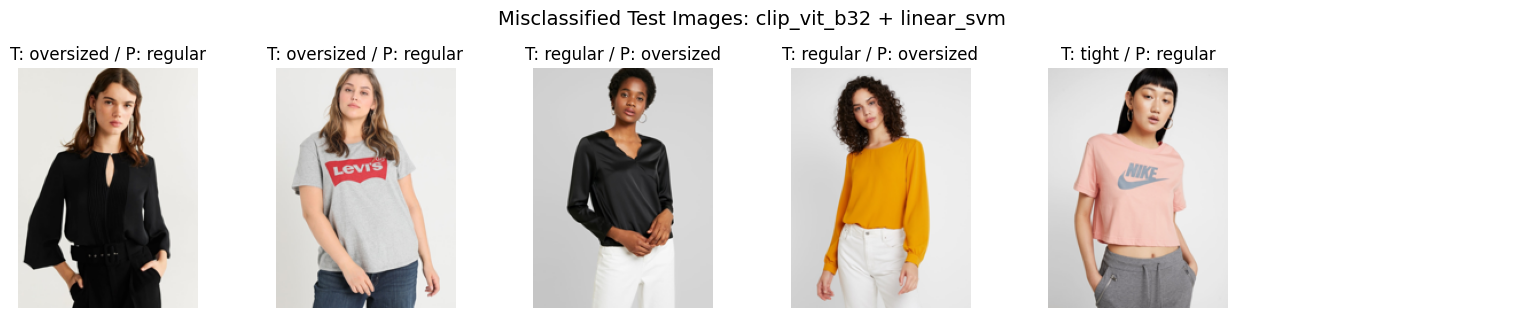

Saved misclassified grid: /content/drive/MyDrive/ML/results/experiment_7/misclassified_grid.png


In [49]:
MAX_GRID_IMAGES = 36
GRID_COLS = 6
THUMB_SIZE = (160, 210)

sample_df = misclassified_df.head(MAX_GRID_IMAGES).copy()

if len(sample_df) == 0:
    print("No misclassified images. Grid was not created.")
else:
    rows = int(np.ceil(len(sample_df) / GRID_COLS))
    fig, axes = plt.subplots(rows, GRID_COLS, figsize=(GRID_COLS * 2.6, rows * 3.2))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row["path"]).convert("RGB")
        image.thumbnail(THUMB_SIZE)
        ax.imshow(image)
        ax.set_title(
            f"T: {row['true_label']} / P: {row['pred_label']}",
        )
        ax.axis("off")

    plt.suptitle(
        f"Misclassified Test Images: {BEST_ENCODER} + {BEST_CLASSIFIER}",
        fontsize=14,
    )
    plt.tight_layout()

    grid_path = RESULT_DIR / "misclassified_grid.png"
    plt.savefig(grid_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved misclassified grid: {grid_path}")


## 20. 오분류 요약

최종 test set에서 어떤 클래스 간 오분류가 많이 발생했는지 표로 확인한다.

예를 들어 실제 `regular` 이미지가 `tight`로 예측되었는지, 또는 실제 `tight` 이미지가 `regular`로 예측되었는지 등을 확인하여 모델이 어려워하는 fit label 경계를 분석한다.

In [50]:
if len(misclassified_df) == 0:
    print("No misclassified images.")
else:
    error_summary = (
        misclassified_df
        .groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    error_summary_path = RESULT_DIR / "misclassification_summary.csv"
    error_summary.to_csv(error_summary_path, index=False, encoding="utf-8-sig")

    display(error_summary)
    print(f"Saved misclassification summary: {error_summary_path}")

,true_label,pred_label,count
0,oversized,regular,2
1,regular,oversized,2
2,tight,regular,1


Saved misclassification summary: /content/drive/MyDrive/ML/results/experiment_7/misclassification_summary.csv
